<a href="https://colab.research.google.com/github/AshakUmesh/Learn-Python/blob/main/Ciphers/IS_Ciphers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Diffusion Results (Shift Cipher) ===
 Position Changed Original Char Replaced With Modified Plaintext  Ciphertext  Bit Differences  Diffusion Score
                1             H             A        AELLO WORLD DHOOR ZRUOG                4         0.045455
                1             H             B        BELLO WORLD EHOOR ZRUOG                3         0.034091
                1             H             C        CELLO WORLD FHOOR ZRUOG                3         0.034091
                1             H             D        DELLO WORLD GHOOR ZRUOG                2         0.022727
                1             H             E        EELLO WORLD HHOOR ZRUOG                2         0.022727
                1             H             F        FELLO WORLD IHOOR ZRUOG                1         0.011364
                1             H             G        GELLO WORLD JHOOR ZRUOG                1         0.011364
                1             H             I        IELLO WORLD LHOOR

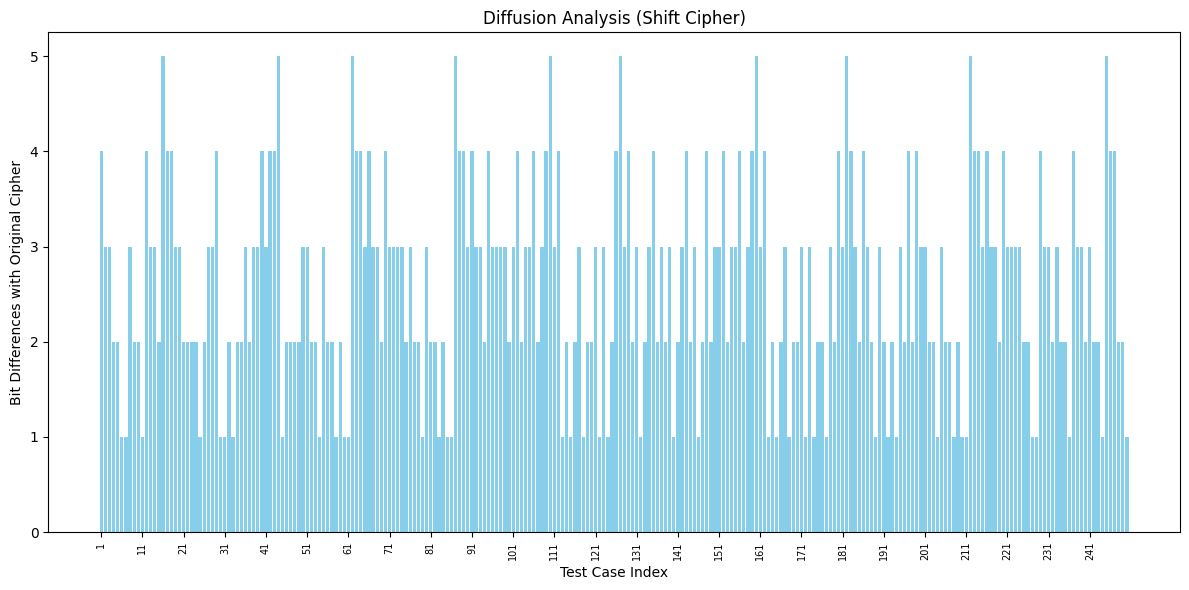

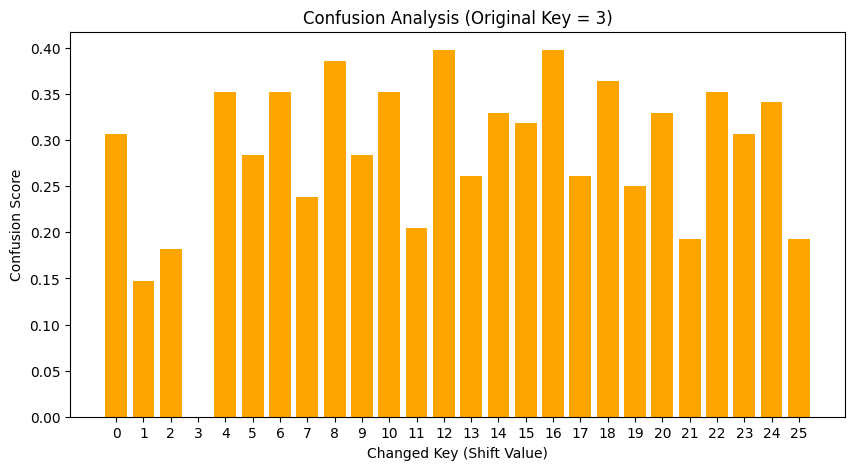

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Shift Cipher
# =========================
def shift_cipher_encrypt(text, shift=3):
    """Encrypt plaintext with Caesar shift cipher."""
    result = ""
    for char in text:
        if char.isalpha():
            base = ord('A') if char.isupper() else ord('a')
            result += chr((ord(char) - base + shift) % 26 + base)
        else:
            result += char
    return result

# =========================
# Hamming distance (bit-level)
# =========================
def hamming_distance_bits(s1, s2):
    """Bitwise Hamming distance between two equal-length strings."""
    xor_result = [ord(a) ^ ord(b) for a, b in zip(s1, s2)]
    return sum(bin(x).count('1') for x in xor_result)

def normalized_distance(s1, s2):
    """Fraction of differing bits (0–1)."""
    return hamming_distance_bits(s1, s2) / (len(s1) * 8)

# =========================
# Diffusion Experiment
# =========================
def diffusion_experiment(plaintext, key=3):
    """Measure diffusion: change one char at a time and re-encrypt."""
    original_cipher = shift_cipher_encrypt(plaintext, key)
    bits_total = len(original_cipher) * 8
    results = []

    for i, ch in enumerate(plaintext):
        if ch == " ":
            continue  # skip spaces

        for replacement in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
            if replacement == ch:
                continue  # skip identical replacement

            modified = plaintext[:i] + replacement + plaintext[i+1:]
            var_cipher = shift_cipher_encrypt(modified, key)

            bit_diff = hamming_distance_bits(original_cipher, var_cipher)
            results.append({
                "Position Changed": i + 1,
                "Original Char": ch,
                "Replaced With": replacement,
                "Modified Plaintext": modified,
                "Ciphertext": var_cipher,
                "Bit Differences": bit_diff,
                "Diffusion Score": bit_diff / bits_total
            })

    return pd.DataFrame(results)

# =========================
# Confusion Experiment
# =========================
def confusion_experiment(plaintext, original_key=3):
    """Measure confusion: change key and re-encrypt."""
    original_cipher = shift_cipher_encrypt(plaintext, original_key)
    bits_total = len(original_cipher) * 8
    results = []

    for key in range(26):
        if key == original_key:
            continue  # skip identical key

        var_cipher = shift_cipher_encrypt(plaintext, key)
        bit_diff = hamming_distance_bits(original_cipher, var_cipher)

        results.append({
            "Original Key": original_key,
            "Changed Key": key,
            "Ciphertext": var_cipher,
            "Bit Differences": bit_diff,
            "Confusion Score": bit_diff / bits_total
        })

    return pd.DataFrame(results)

# =========================
# Run Experiments (Shift Cipher)
# =========================
plaintext = "HELLO WORLD"
original_key = 3

# Diffusion
df_diffusion = diffusion_experiment(plaintext, key=original_key)
print("\n=== Diffusion Results (Shift Cipher) ===")
print(df_diffusion.to_string(index=False))  # ✅ print entire DataFrame

print(f"\nTotal tests run: {len(df_diffusion)}")
print("Average Diffusion Score:", df_diffusion["Diffusion Score"].mean())

# Confusion
df_confusion = confusion_experiment(plaintext, original_key=original_key)
print("\n=== Confusion Results (Shift Cipher) ===")
print(df_confusion.to_string(index=False))  # ✅ full DataFrame

print(f"\nTotal tests run: {len(df_confusion)}")
print("\n")
print("Average Confusion Score:", df_confusion['Confusion Score'].mean())
print("\n\n\n")
# =========================
# Plots
# =========================
# Diffusion visualization (simplified X-axis)
# Diffusion visualization (with numeric X-axis)
plt.figure(figsize=(12,6))
plt.bar(range(len(df_diffusion)), df_diffusion["Bit Differences"], color="skyblue")

# show only every 10th tick
step = 10
plt.xticks(
    range(0, len(df_diffusion), step),
    range(1, len(df_diffusion)+1, step),
    rotation=90,
    fontsize=7
)

plt.ylabel("Bit Differences with Original Cipher")
plt.xlabel("Test Case Index")
plt.title("Diffusion Analysis (Shift Cipher)")
plt.tight_layout()
plt.show()




print("\n\n\n")
# Confusion visualization
plt.figure(figsize=(10,5))
plt.bar(df_confusion["Changed Key"], df_confusion["Confusion Score"], color="orange")
plt.xlabel("Changed Key (Shift Value)")
plt.ylabel("Confusion Score")
plt.title(f"Confusion Analysis (Original Key = {original_key})")
plt.xticks(range(26))
plt.show()



=== Diffusion Analysis (ADFGVX) ===

 Position Changed Original Char Replaced With Modified Plaintext       Ciphertext  Bit Differences  Diffusion Score
                1             H             A           AELLO123 ADXVVAVDFVXAXFGV                4         0.031250
                1             H             B           BELLO123 DDXVVAVDFVXAXFGV                2         0.015625
                1             H             C           CELLO123 FDXVVAVDFVXAXFGV                3         0.023438
                1             H             D           DELLO123 GDXVVAVDFVXAXFGV                4         0.031250
                1             H             E           EELLO123 VDXVVAVDFVXAXFGV                4         0.031250
                1             H             F           FELLO123 XDXVVAVDFVXAXFGV                5         0.039062
                1             H             G           GELLO123 ADXVVDVDFVXAXFGV                2         0.015625
                1             H   

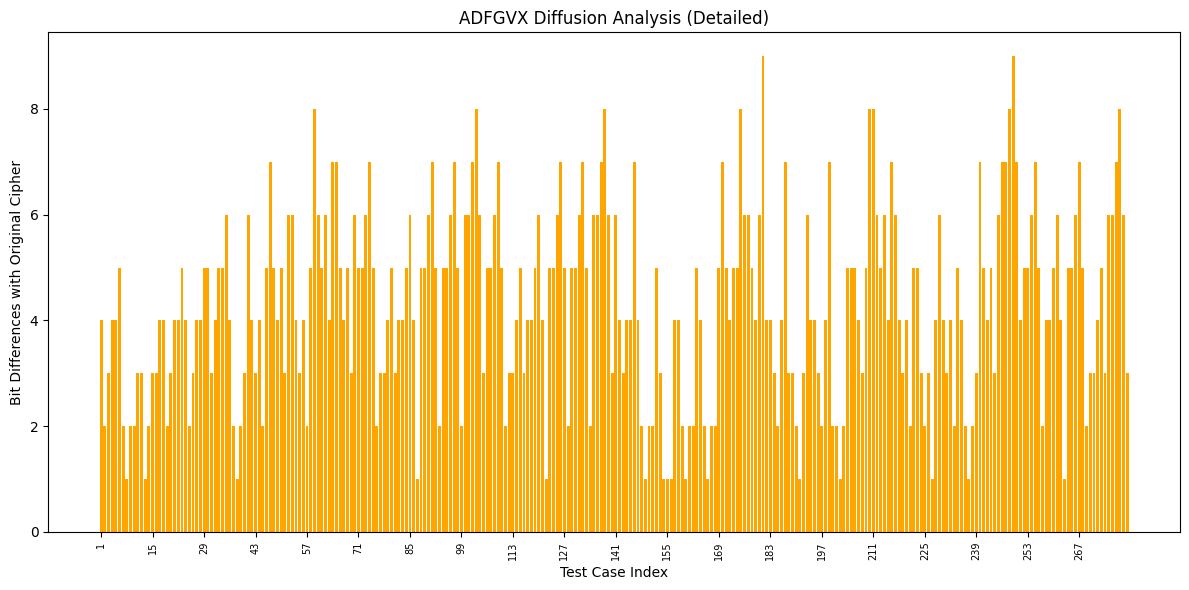

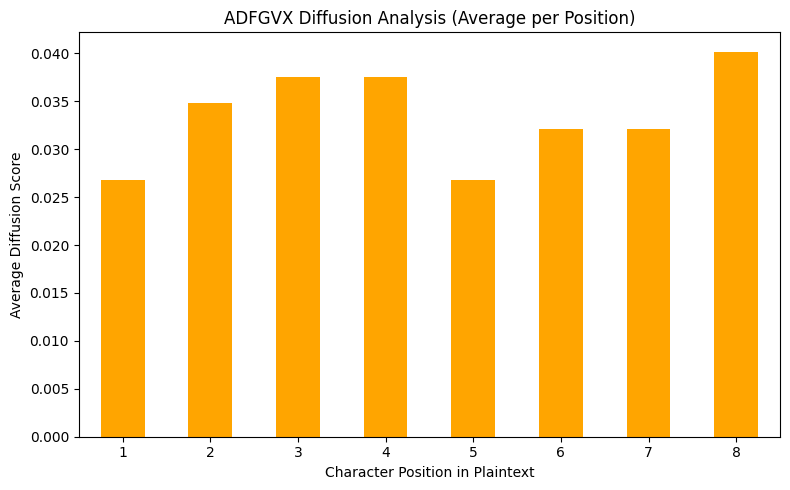


=== Confusion Analysis (ADFGVX) ===

Original Key Changed Key Ciphertext (Changed Key)  Bit Differences  Confusion Score
         KEY         AEY         DVDFVXDDXVVAXFGV               18         0.140625
         KEY         BEY         DVDFVXDDXVVAXFGV               18         0.140625
         KEY         CEY         DVDFVXDDXVVAXFGV               18         0.140625
         KEY         DEY         DVDFVXDDXVVAXFGV               18         0.140625
         KEY         EEY         DVDFVXDDXVVAXFGV               18         0.140625
         KEY         FEY         DDXVVDVDFVXAXFGV                0         0.000000
         KEY         GEY         DDXVVDVDFVXAXFGV                0         0.000000
         KEY         HEY         DDXVVDVDFVXAXFGV                0         0.000000
         KEY         IEY         DDXVVDVDFVXAXFGV                0         0.000000
         KEY         JEY         DDXVVDVDFVXAXFGV                0         0.000000
         KEY         LEY         DDXVV

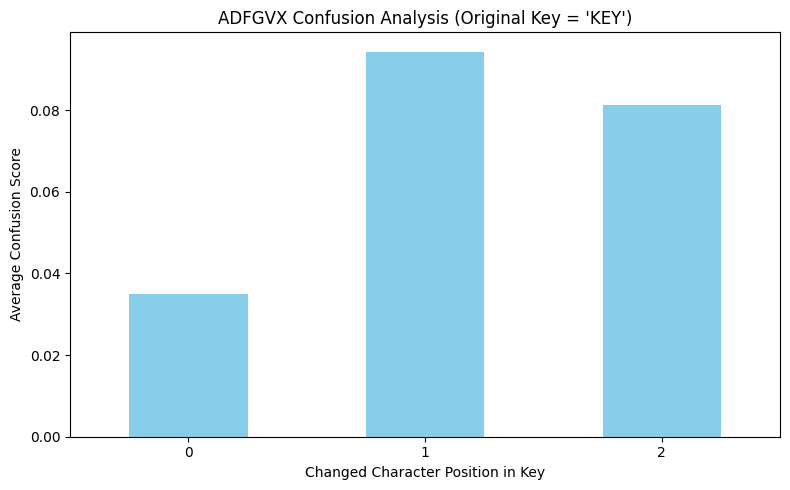

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import string

# -----------------------------
# ADFGVX Cipher Implementation
# -----------------------------
symbols = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
adfgvx = "ADFGVX"

# Polybius square mapping
polybius_square = {}
i = 0
for r in adfgvx:
    for c in adfgvx:
        polybius_square[symbols[i]] = r + c
        i += 1

def adfgvx_encrypt(plaintext, key):
    """Encrypt plaintext with ADFGVX cipher (Polybius + columnar transposition)."""
    plaintext = plaintext.upper().replace(" ", "")

    # Step 1: substitution using Polybius square
    substituted = "".join(polybius_square[ch] for ch in plaintext if ch in polybius_square)

    # Step 2: columnar transposition
    cols = len(key)
    rows = math.ceil(len(substituted) / cols)
    grid = [[""] * cols for _ in range(rows)]

    for i, ch in enumerate(substituted):
        grid[i // cols][i % cols] = ch

    # Sort key for transposition
    sorted_key = sorted([(ch, i) for i, ch in enumerate(key)])

    ciphertext = ""
    for _, idx in sorted_key:
        for row in grid:
            if row[idx] != "":
                ciphertext += row[idx]
    return ciphertext

# -----------------------------
# Helper Functions
# -----------------------------
def hamming_distance_bits(s1, s2):
    """Bitwise Hamming distance between two equal-length strings."""
    xor_result = [ord(a) ^ ord(b) for a, b in zip(s1, s2)]
    return sum(bin(x).count("1") for x in xor_result)

def diffusion_score(s1, s2):
    return hamming_distance_bits(s1, s2) / (len(s1) * 8)

def confusion_score(s1, s2):
    return hamming_distance_bits(s1, s2) / (len(s1) * 8)

# -----------------------------
# Diffusion Analysis
# -----------------------------
plaintext = "HELLO123"
key = "KEY"

original_cipher = adfgvx_encrypt(plaintext, key)
bits_total = len(original_cipher) * 8

diffusion_results = []

for i, ch in enumerate(plaintext):
    for replacement in symbols:
        if replacement == ch:
            continue
        modified = plaintext[:i] + replacement + plaintext[i+1:]
        var_cipher = adfgvx_encrypt(modified, key)
        bit_diff = hamming_distance_bits(original_cipher, var_cipher)
        score = diffusion_score(original_cipher, var_cipher)
        diffusion_results.append({
            "Position Changed": i + 1,
            "Original Char": ch,
            "Replaced With": replacement,
            "Modified Plaintext": modified,
            "Ciphertext": var_cipher,
            "Bit Differences": bit_diff,
            "Diffusion Score": score
        })

df_diffusion = pd.DataFrame(diffusion_results)

print("\n=== Diffusion Analysis (ADFGVX) ===\n")
print(df_diffusion.to_string(index=False))
print("\nTotal rows:", df_diffusion.shape[0])
print("Average Diffusion Score:", df_diffusion["Diffusion Score"].mean())

# Detailed diffusion plot (indices only)
plt.figure(figsize=(12,6))
plt.bar(range(len(df_diffusion)), df_diffusion["Bit Differences"], color="orange")
plt.xticks(
    range(0, len(df_diffusion), max(1, len(df_diffusion)//20)),  # show ~20 labels max
    range(1, len(df_diffusion)+1, max(1, len(df_diffusion)//20)),
    rotation=90,
    fontsize=7
)
plt.ylabel("Bit Differences with Original Cipher")
plt.xlabel("Test Case Index")
plt.title("ADFGVX Diffusion Analysis (Detailed)")
plt.tight_layout()
plt.show()

# Grouped diffusion plot (average per position)
avg_by_pos = df_diffusion.groupby("Position Changed")["Diffusion Score"].mean()
plt.figure(figsize=(8,5))
avg_by_pos.plot(kind="bar", color="orange")
plt.ylabel("Average Diffusion Score")
plt.xlabel("Character Position in Plaintext")
plt.title("ADFGVX Diffusion Analysis (Average per Position)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -----------------------------
# Confusion Analysis
# -----------------------------
def generate_key_variations(key, alphabet=string.ascii_uppercase):
    """Generate keys with single-character substitutions."""
    variations = []
    for i, ch in enumerate(key):
        for repl in alphabet:
            if repl != ch:
                new_key = key[:i] + repl + key[i+1:]
                variations.append(new_key)
    return variations

original_key = "KEY"
original_cipher_conf = adfgvx_encrypt(plaintext, original_key)
bits_total_conf = len(original_cipher_conf) * 8

confusion_results = []

key_variations = generate_key_variations(original_key)

for test_key in key_variations:
    var_cipher = adfgvx_encrypt(plaintext, test_key)
    bit_diff = hamming_distance_bits(original_cipher_conf, var_cipher)
    score = confusion_score(original_cipher_conf, var_cipher)
    confusion_results.append({
        "Original Key": original_key,
        "Changed Key": test_key,
        "Ciphertext (Changed Key)": var_cipher,
        "Bit Differences": bit_diff,
        "Confusion Score": score
    })

df_confusion = pd.DataFrame(confusion_results)

print("\n=== Confusion Analysis (ADFGVX) ===\n")
print(df_confusion.to_string(index=False))
print("\nTotal rows:", df_confusion.shape[0])
print("Average Confusion Score:", df_confusion["Confusion Score"].mean())

# Plot confusion results (average by character position in key)
df_confusion["Changed Position"] = [
    next(i for i in range(len(original_key)) if original_key[i] != new[i])
    for new in df_confusion["Changed Key"]
]
avg_conf_by_pos = df_confusion.groupby("Changed Position")["Confusion Score"].mean()

plt.figure(figsize=(8,5))
avg_conf_by_pos.plot(kind="bar", color="skyblue")
plt.xlabel("Changed Character Position in Key")
plt.ylabel("Average Confusion Score")
plt.title(f"ADFGVX Confusion Analysis (Original Key = '{original_key}')")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
